In [1]:
from jitcdde import t
from toyParameters import *
import numpy as np
import matplotlib.pyplot as plt
from msrDynamics import Node, System

Instantiate System Object & Nodes

In [2]:
# MSR system        
MSR = System()

# core nodes
cf_in = Node(m = m_f_c/2, scp = scp_f, W = W_f, y0 = T0_c_f1)  # core fuel inlet
cf_out = Node(m = m_f_c/2, scp = scp_f, W = W_f, y0 = T0_c_f2) # core fuel outlet
cm = Node(m = m_m_c, scp = scp_m, y0 = T0_c_m)                 # core moderator

n = Node(y0 = n_frac0)     # fractional neutron density
C1 = Node(y0 = C0[0])      # precursor group 1
C2 = Node(y0 = C0[1])      # precursor group 2
C3 = Node(y0 = C0[2])      # precursor group 3
C4 = Node(y0 = C0[3])      # precursor group 4
C5 = Node(y0 = C0[4])      # precursor group 5
C6 = Node(y0 = C0[5])      # precursor group 6
rho = Node(y0 = 0.0)       # reactivity

# heat exchanger nodes 
hx_p_in = Node(m = m_f_hx, scp = scp_f, W = W_f, y0 = T0_hfh_f1)     # hx primary circuit inlet
hx_p_out = Node(m = m_f_hx, scp = scp_f, W = W_f, y0 = T0_hfh_f2)    # hx primary circuit outlet
hx_t = Node(m = m_t_hxfh, scp = scp_t, y0 = T0_hfh_t1)                   # hx tubes
hx_s_in = Node(m = m_h_hxfh, scp = scp_h, W = W_h_fh, y0 = T0_hfh_h1)  # hx secondary circuit inlet
hx_s_out = Node(m = m_h_hxfh, scp = scp_h, W = W_h_fh, y0 = T0_hfh_h2) # hx secondary circuit outlet

# populate system 
MSR.add_nodes([cf_in,cf_out,cm,n,C1,C2,C3,C4,C5,C6,rho,
              hx_p_in,hx_p_out,hx_t,hx_s_in,hx_s_out])

Define Dynamics

In [3]:
# core
cf_in.set_dTdt_advective(source = hx_p_out.y(t-tau_hx_c_f)) 
cf_in.set_dTdt_internal(source = n.y(), k = k_f1*P)
cf_in.set_dTdt_convective(source = [cm.y()], hA = [hA_ft_c/2])

cf_out.set_dTdt_advective(source = cf_in.y()) 
cf_out.set_dTdt_internal(source = n.y(), k = k_f2*P)
cf_out.set_dTdt_convective(source = [cm.y()], hA = [hA_ft_c/2])

cm.set_dTdt_internal(source = n.y(), k = k_m*P)
cm.set_dTdt_convective(source = [cf_in.y(), cf_out.y()], hA = [hA_mc_c/2]*2)

n.set_dndt(rho.y(), beta_t, Lam, lam, [C1.y(), C2.y(), C3.y(), C4.y(), C5.y(), C6.y()])
C1.set_dcdt(n.y(), beta[0], Lam, lam[0], True, tau_c, tau_l)
C2.set_dcdt(n.y(), beta[1], Lam, lam[1], True, tau_c, tau_l)
C3.set_dcdt(n.y(), beta[2], Lam, lam[2], True, tau_c, tau_l)
C4.set_dcdt(n.y(), beta[3], Lam, lam[3], True, tau_c, tau_l)
C5.set_dcdt(n.y(), beta[4], Lam, lam[4], True, tau_c, tau_l)
C6.set_dcdt(n.y(), beta[5], Lam, lam[5], True, tau_c, tau_l)
rho.set_drdt([cf_in.dydt(),cf_out.dydt(),cm.dydt()],[a_f/2,a_f/2,a_b])

# heat exchanger
hx_p_in.set_dTdt_advective(source = cf_out.y(t-tau_c_hx_f))
hx_p_in.set_dTdt_convective(source = [hx_t.y()], hA = [hA_ft_hx])

hx_p_out.set_dTdt_advective(source = hx_p_in.y())
hx_p_out.set_dTdt_convective(source = [hx_t.y()], hA = [hA_ft_hx])

hx_t.set_dTdt_convective(source = [hx_p_in.y(),hx_p_out.y(),hx_s_in.y(),hx_s_out.y()],
                              hA = [hA_ft_hx, hA_ft_hx, hA_ht_hx, hA_ht_hx])

hx_s_in.set_dTdt_advective(source = 50)
hx_s_in.set_dTdt_convective(source = [hx_t.y()], hA = [hA_ht_hx])

hx_s_out.set_dTdt_advective(source = hx_s_in.y())
hx_s_out.set_dTdt_convective(source = [hx_t.y()], hA = [hA_ht_hx])

In [4]:
# finalize & solve
T = np.arange(0,1000,0.01)
sol_jit = MSR.solve(T)

Generating, compiling, and loading C code.
Using default integration parameters.


c:\Users\hanse\AppData\Local\Programs\Python\Python312\Lib\site-packages\msrDynamics\system_objects.py:130: UserWarning: You did not explicitly handle initial discontinuities. Proceed only if you know what you are doing. This is only fine if you somehow chose your initial past such that the derivative of the last anchor complies with the DDE. In this case, you can set the attribute `initial_discontinuities_handled` to `True` to suppress this warning. See https://jitcdde.rtfd.io/#discontinuities for details.
  y.append(self.integrator.integrate(t_x))
c:\Users\hanse\AppData\Local\Programs\Python\Python312\Lib\site-packages\msrDynamics\system_objects.py:130: UserWarning: The target time is smaller than the current time. No integration step will happen. The returned state will be extrapolated from the interpolating Hermite polynomial for the last integration step. You may see this because you try to integrate backwards in time, in which case you did something wrong. You may see this just b

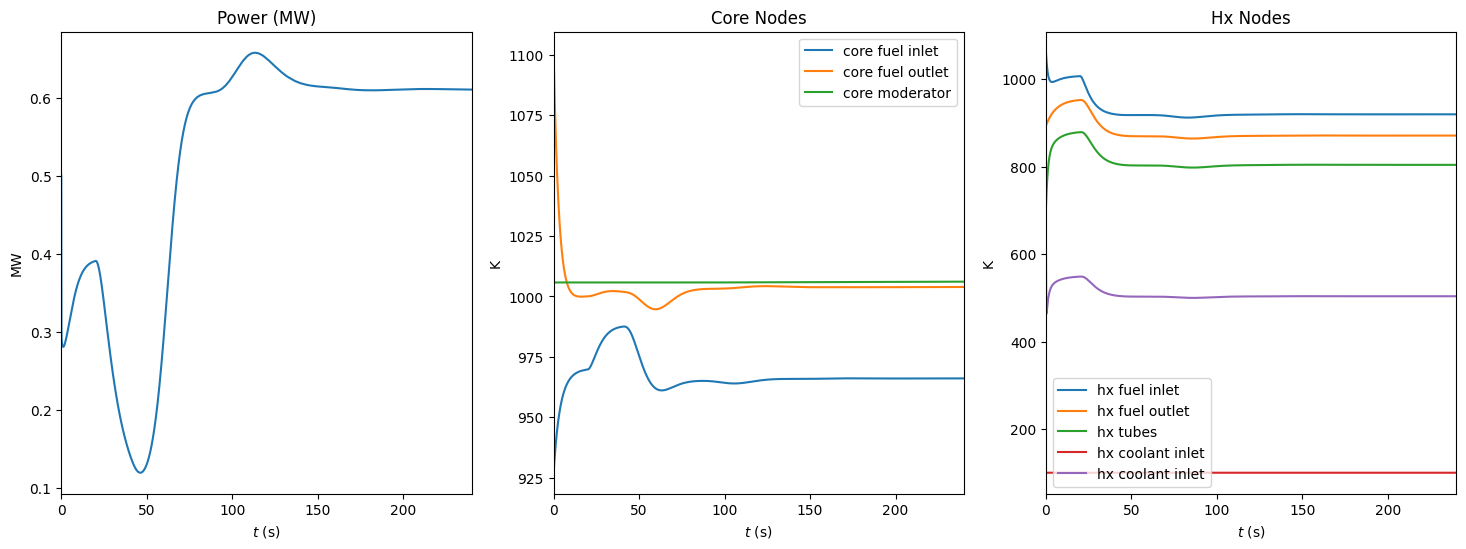

In [5]:
fig,axs = plt.subplots(1,3,figsize=(18,6))

t0 = 0.0
tf = 240.00

# P
axs[0].plot(T, [k*P for k in n.y_out])
axs[0].set_xlim(t0,tf)
axs[0].set_title("Power (MW)")
axs[0].set_xlabel(r"$t$ (s)")
axs[0].set_ylabel("MW")

# core temps 
axs[1].plot(T, cf_in.y_out, label = "core fuel inlet")
axs[1].plot(T, cf_out.y_out, label = "core fuel outlet")
axs[1].plot(T, cm.y_out, label = "core moderator")
axs[1].legend()
axs[1].set_xlim(t0,tf)
axs[1].set_xlabel(r"$t$ (s)")
axs[1].set_ylabel("K")
axs[1].set_title("Core Nodes")

# hx temps
axs[2].plot(T,hx_p_in.y_out,label = "hx fuel inlet")
axs[2].plot(T,hx_p_out.y_out,label = "hx fuel outlet")
axs[2].plot(T,hx_t.y_out,label = "hx tubes")
axs[2].plot(T,[100]*len(T),label = "hx coolant inlet")
axs[2].plot(T,hx_s_out.y_out,label = "hx coolant inlet")
axs[2].set_xlim(t0,tf)
axs[2].set_xlabel(r"$t$ (s)")
axs[2].set_ylabel("K")
axs[2].set_title("Hx Nodes")
axs[2].legend()